# California Residential Home Price Prediction
# Exploration Notebook

## Section 1 - Setup & Data Loading

**Dataset:** CRMLS MLS data sourced via IDX Exchange FTP  
**Target:** ClosePrice (final sale price)  
**Scope:** Single Family Residential properties in California, Jan 2022 – May 2026

This notebook covers exploratory data analysis - understanding distributions, spotting outliers, and identifying patterns before any preprocessing or modeling.

In [4]:
import pandas as pd
import glob
import os

# Load all CSVs at once
files = glob.glob('/Users/granthbangard/Local Files/Documents/granth/UIUC/IDXExchange/DataSet/CRMLSSold*.csv')
df = pd.concat([pd.read_csv(f, low_memory = False) for f in files], ignore_index = True)

In [5]:
# Basic orientation
print('Shape:', df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

Shape: (794271, 82)
['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'Con

In [6]:
# Filtering PropertyType to include only Residential SingleFamilyResidence

df_sfr = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

print('shape:', df_sfr.shape, '\n')
print(df_sfr[['ClosePrice', 'Latitude', 'Longitude', 'ElementarySchoolDistrict', 'HighSchoolDistrict', 'latfilled', 'lonfilled']].isnull().sum())

shape: (399157, 82) 

ClosePrice                       2
Latitude                       193
Longitude                      193
ElementarySchoolDistrict    399157
HighSchoolDistrict          103300
latfilled                   230343
lonfilled                   230343
dtype: int64


## Section 2 — Target Variable & Core Features Distributions

ClosePrice is the value we're predicting. Before building anything, it's worth understanding what the distribution actually looks like — real estate prices are heavily right-skewed, which has implications for modeling.

Below that, distributions for the core property features: living area, bedrooms, bathrooms, lot size, and year built.

Note - ClosePrice distribution is capped at $5M for visualization - extreme outliers ($989.5 Million) exist but obscure the main distribution. Features capped at realistic limits for visualization - outliers addressed in preprocessing.

### ClosePrice Histogram

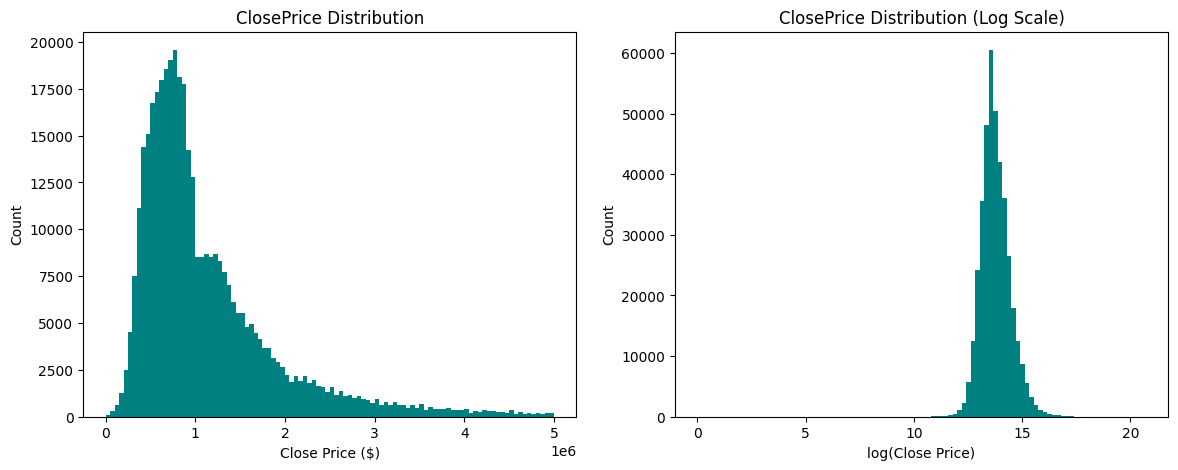

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Regular Scale
axes[0].hist(df_sfr[df_sfr['ClosePrice'] < 5000000]['ClosePrice'].dropna(), bins = 100, color = 'teal')
axes[0].set_title("ClosePrice Distribution")
axes[0].set_xlabel("Close Price ($)")
axes[0].set_ylabel("Count")

# Log Scale
axes[1].hist(np.log1p(df_sfr['ClosePrice'].dropna()), bins = 100, color = 'teal')
axes[1].set_title('ClosePrice Distribution (Log Scale)')
axes[1].set_xlabel('log(Close Price)')
axes[1].set_ylabel('Count')

plt.show()

### Core feature subplots

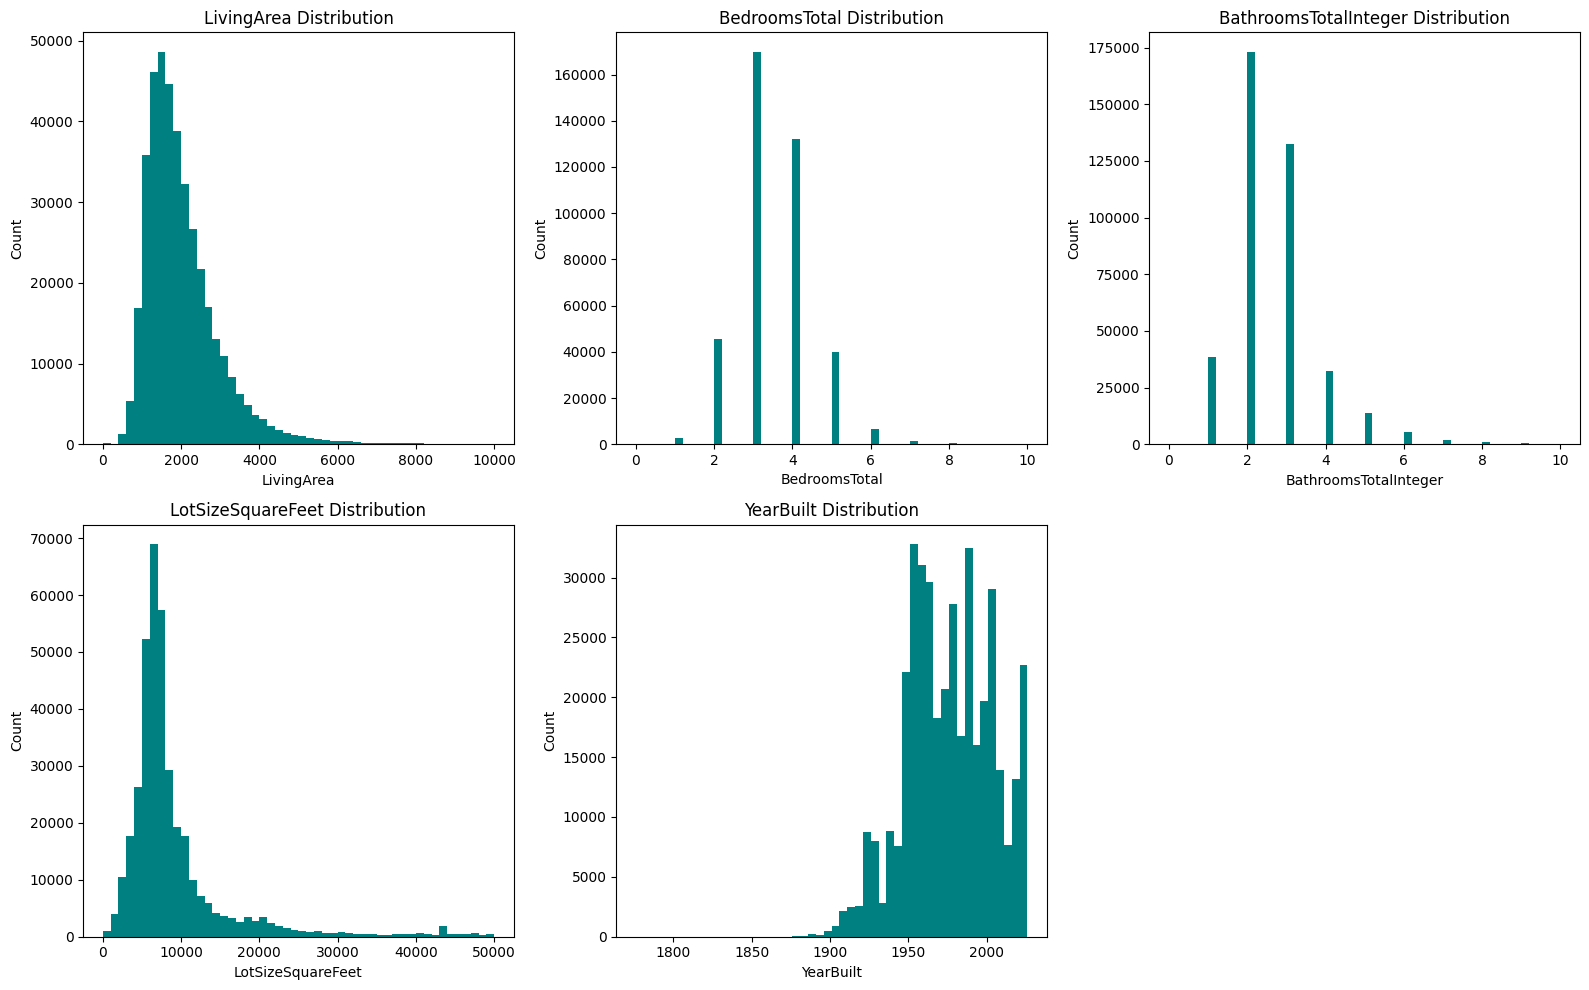

In [44]:
features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt']

caps = {
    'LivingArea': 10000,
    'BedroomsTotal': 10,
    'BathroomsTotalInteger': 10,
    'LotSizeSquareFeet': 50000,
    'YearBuilt': None  # no cap needed, already looks good
}

fig, axes = plt.subplots(2, 3, figsize = (16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_sfr[col].dropna()
    if caps[col]:
        data = data[data <= caps[col]]
    axes[i].hist(data, bins=50, color='teal')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
df_sfr[['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt']].describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt
count,3.991550e+05,3.989470e+05,399157.000000,399082.000000,3.923310e+05,398849.000000
mean,1.285092e+06,2.036718e+03,3.476710,2.610133,2.454994e+05,1975.388530
std,5.237207e+06,3.803275e+03,0.960517,1.182700,1.387443e+07,27.419481
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1776.000000
25%,6.200000e+05,1.373000e+03,3.000000,2.000000,5.663000e+03,1955.000000
50%,8.890000e+05,1.800000e+03,3.000000,2.000000,7.247000e+03,1975.000000
75%,1.425000e+06,2.417500e+03,4.000000,3.000000,1.034000e+04,1997.000000
max,9.895000e+08,2.308680e+06,45.000000,175.000000,2.087221e+09,2026.000000


## Section 3 - Outliers & Feature Correlations

Extreme values in real estate data are common - a $50M estate and a $200K starter home both show up in the same dataset. The question is whether they're real transactions or data errors, and whether keeping them helps or hurts the model.

The correlation heatmap shows which numeric features move with ClosePrice and which don't - a first signal for feature selection.

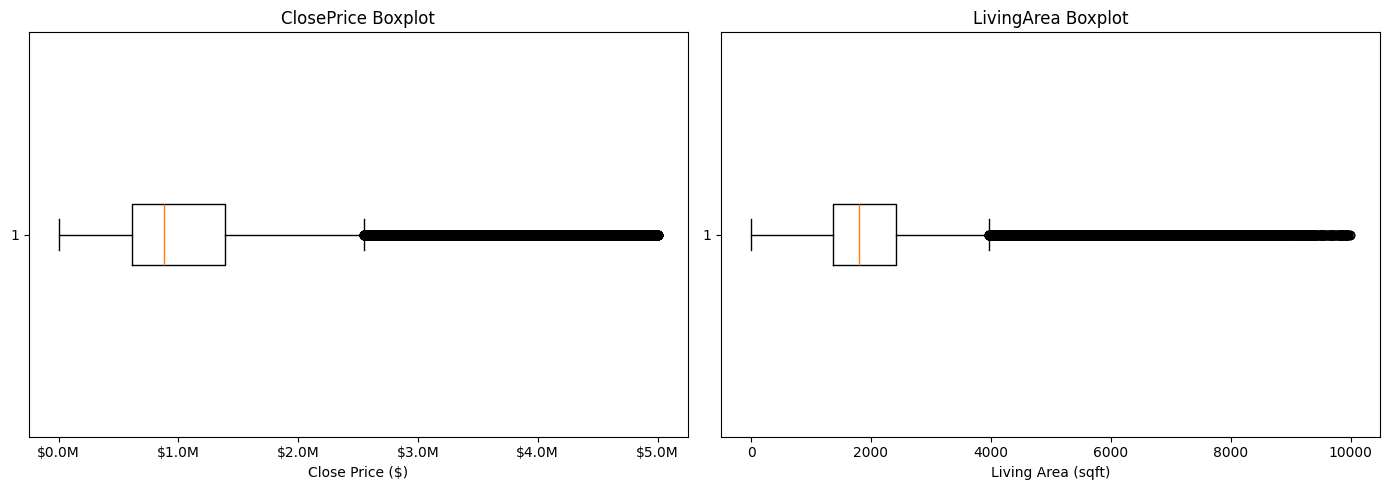

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_sfr[df_sfr['ClosePrice'] < 5000000]['ClosePrice'].dropna(), vert=False)
axes[0].set_title('ClosePrice Boxplot')
axes[0].set_xlabel('Close Price ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].boxplot(df_sfr[df_sfr['LivingArea'] < 10000]['LivingArea'].dropna(), vert=False)
axes[1].set_title('LivingArea Boxplot')
axes[1].set_xlabel('Living Area (sqft)')

plt.tight_layout()
plt.show()

In [11]:
total = len(df_sfr)
pct_5m = (df_sfr['ClosePrice'] > 5000000).sum() / total * 100
pct_10k = (df_sfr['LivingArea'] > 10000).sum() / total * 100

print(f'Records above $5M: {pct_5m:.2f}%')
print(f'Records above 10,000 sqft: {pct_10k:.2f}%')

Records above $5M: 1.60%
Records above 10,000 sqft: 0.11%


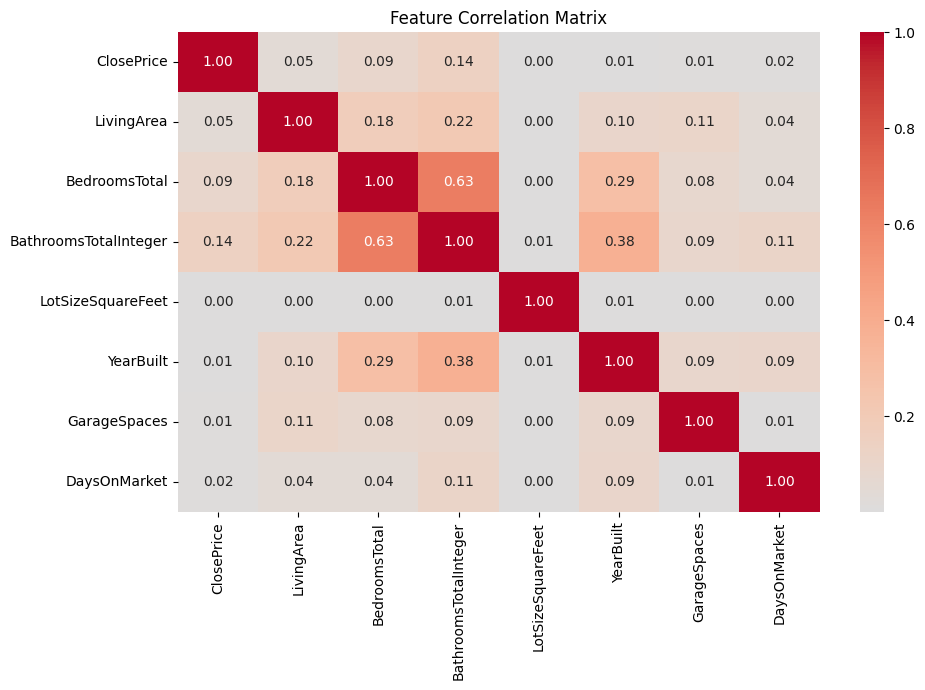

In [12]:
import seaborn as sns

numeric_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'DaysOnMarket']

corr = df_sfr[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Section 4 - Geographic & Temporal Trends

California real estate is highly location-dependent - a 1,500 sqft home in Orange County and the same home in the Central Valley are completely different assets. This section looks at price variation by county and how the market moved over time.

The temporal view captures the full market cycle from 2022 through 2026: the rate-driven slowdown in late 2022, the recovery through 2023, the peak in mid-2024, and the stabilization that followed.

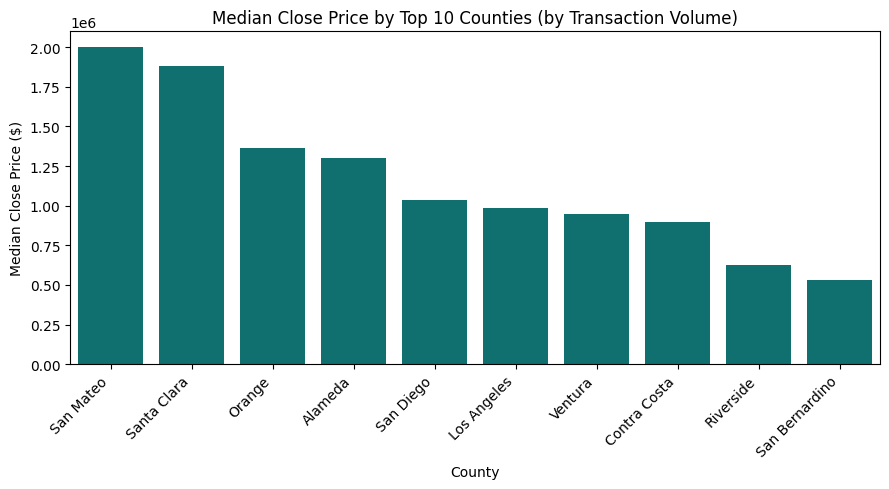

In [45]:
top_10_counties = df_sfr.groupby("CountyOrParish")["ClosePrice"].agg(["median", "count"]).reset_index().sort_values("count", ascending = False).head(10).sort_values("median", ascending = False)
top_10_counties

plt.figure(figsize=(9, 5))
sns.barplot(top_10_counties, x = "CountyOrParish", y = "median", color = "teal")
plt.title('Median Close Price by Top 10 Counties (by Transaction Volume)')
plt.xlabel('County')
plt.ylabel('Median Close Price ($)')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

In [14]:
df_sfr['CloseDate'] = pd.to_datetime(df_sfr['CloseDate'], errors='coerce')
df_sfr['YearMonth'] = df_sfr['CloseDate'].dt.to_period('M')

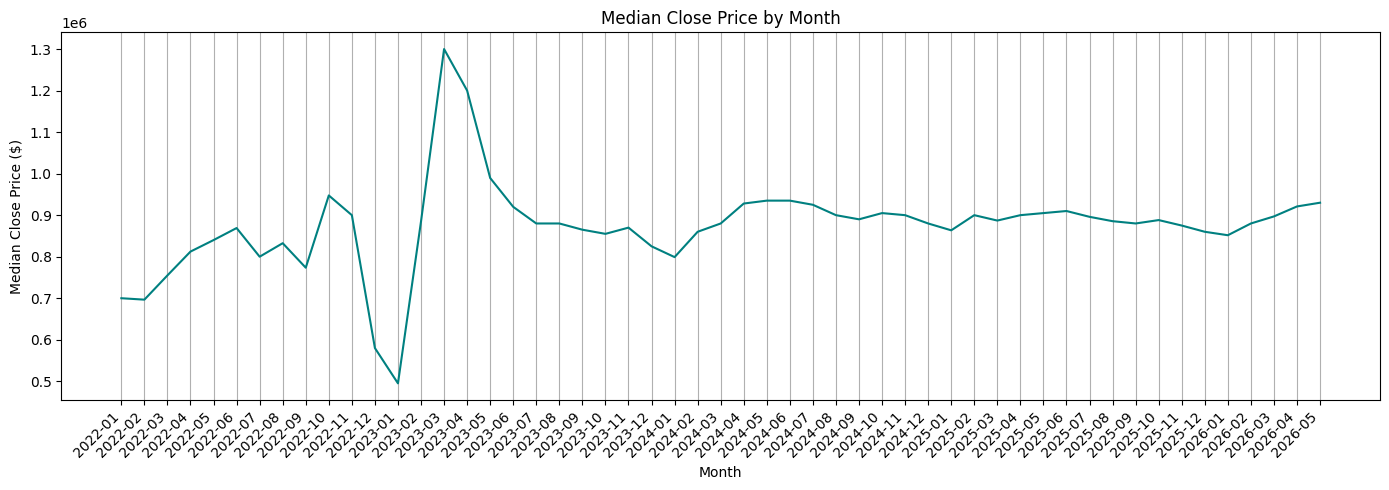

In [46]:
median_closeprice = df_sfr.groupby("YearMonth")["ClosePrice"].agg("median").reset_index()
median_closeprice['YearMonth'] = median_closeprice['YearMonth'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(median_closeprice['YearMonth'], median_closeprice['ClosePrice'], color = "teal")
plt.title('Median Close Price by Month')
plt.xlabel('Month')
plt.ylabel('Median Close Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis = 'x')
plt.tight_layout()
plt.show()

## A Note on Data Completeness

Before reading too much into the temporal trend, it's worth checking how many 
records exist per month. The early months (Jan 2022 – Apr 2023) have suspiciously 
low transaction counts — sometimes under 100 — compared to 8,000–13,000 per month 
from mid-2023 onwards.

This isn't a market slowdown. It's almost certainly incomplete data ingestion for 
those earlier months. A handful of high-value properties in a 17-record month will 
spike the median dramatically, which explains the sharp peak and crash visible in 
the line chart.

**Implication for modeling:** The effective dataset likely starts around June 2023. 
The training window experiment in Week 3 should test whether including pre-2023 
data helps or hurts model performance.

## Section 5 - Key Findings

- ClosePrice is heavily right-skewed; log transformation will likely improve model performance.
- BathroomsTotalInteger has the strongest linear correlation with ClosePrice (0.14) among 
  numeric features - surprisingly weak overall, suggesting location is the dominant price 
  driver in California real estate.
- LotSizeSquareFeet shows near-zero correlation with ClosePrice, likely distorted by extreme 
  outliers (large ranches skewing the distribution).
- Bedrooms and Bathrooms are highly correlated with each other (0.63) - bed/bath ratio 
  will be engineered as a combined feature in preprocessing.
- 1.60% of records fall above $5M and 0.11% above 10,000 sqft - flagged for outlier 
  treatment in preprocessing.
- 193 records are missing Latitude/Longitude - small enough to recover via geocoding.
- ElementarySchoolDistrict is completely empty after SFR filter; school district feature 
  will require a spatial join against CA boundaries in Week 6.
- Early months (Jan 2022 – Apr 2023) have very low record counts, making them unreliable 
  for trend analysis - effective dataset starts June 2023.
- Market peaked around May 2024 and June 2024 at $935,000 median - temporal train/test split is essential 
  to avoid data leakage.